# Homework 1: Center-based clustering :: K-Means

1. Make a copy of this file: `File -> Save a copy in Drive`
2. Complete the assignment by implemeting the `#TODO`s for each question.
3. To submit your assignment, share it with Sayan (sayanb@pdx.edu) and Jeremy (vonder2@pdx.edu) and submit the link to Canvas: `Share -> sayanb@pdx.edu, vonder2@pdx.edu -> Copy link`

In [ ]:
import pandas as pd
import requests
from io import StringIO
import matplotlib.pyplot as plt
import numpy as np

# 1. Old Faithful

Here's a classic dataset of [Old Faithful](https://en.wikipedia.org/wiki/Old_Faithful)'s eruptions.

- Each row of the data represents an eruption.
- The `eruptions` column measures the duration of each eruption in minutes.
- The `waiting` column measures the waiting time since the last eruption, also in minutes.



In [ ]:
old_faithful_url = "http://www.stat.cmu.edu/~larry/all-of-statistics/=data/faithful.dat"

# Download the text file
response = requests.get(old_faithful_url, verify=False)
data = response.text

# Chop off the first 25 lines
data_lines = data.split("\n")[25:]

# Join the remaining lines back into a single string
data_cleaned = "\n".join(data_lines)

# Load the data into a pandas DataFrame
df = pd.read_csv(StringIO(data_cleaned), sep="\s+")

# Print the first few rows of the DataFrame
df

/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning:

Unverified HTTPS request is being made to host 'www.stat.cmu.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings



,eruptions,waiting
1,3.600,79
2,1.800,54
3,3.333,74
4,2.283,62
5,4.533,85
...,...,...
268,4.117,81
269,2.150,46
270,4.417,90
271,1.817,46


## Question 1 (2 points)
Perform K-means with k=2,3,4 and 5 different clusters. How many clusters seems "correct" for this data? Justify your answer **without** appealing to visualizations of the data. (This dataset may be easy to visualize, but higher-dimensional datasets may not be. You should get familiar with methods that work even when visualization is difficult.)


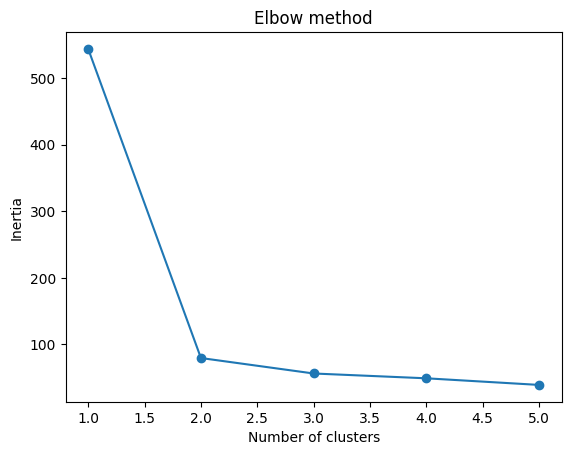

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# normalize dataset
scaler = StandardScaler()
df_std = scaler.fit_transform(df)
sse = [] # SSE meaning sum of squared distances

# fit for k= 1-6
for k in range(1,6):
  kmeans = KMeans(k).fit(df_std)
  sse.append(kmeans.inertia_)

plt.plot(range(1,len(sse)+1), sse, marker='o')
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

After K=2, there's a clear diminishing return and therefore K=2 seems to best fit the data.

## Question 2 (1 points)

How many types of eruptions do you notice?

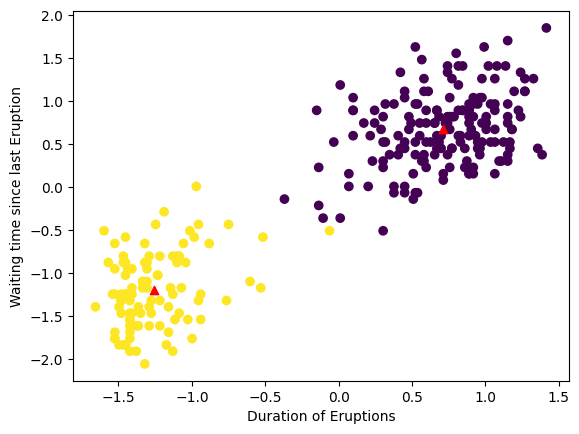

In [ ]:
# TODO: your answer here

# Kmeans using k=2
kmeans = KMeans(2).fit(df_std)
data = np.array(df_std)
centers = np.array(kmeans.cluster_centers_)

plt.figure(1)
plt.scatter(data[:,0],data[:,1],c=kmeans.labels_)
plt.scatter(centers[:,0],centers[:,1],marker = '^',c = 'red')
plt.xlabel('Duration of Eruptions')
plt.ylabel('Waiting time since last Eruption')
plt.show()

Seems to be two types of Eruptions: clustered around Short Duration(<3min) and waiting time
and then long duration(>3.5min) and waiting time.

## Question 3 (1 points)
What percentage of eruptions are of each type?

In [ ]:
# TODO: your answer here
counts = np.bincount(kmeans.labels_)
print('Long Eruptions: ',"{:.2%}".format(counts[0]/sum(counts)))
print('Short Eruptions: ',"{:.2%}".format(counts[1]/sum(counts)))


Long Eruptions:  63.97%
Short Eruptions:  36.03%


## 2. Choosing a Color Pallette

Modern digital images typically represent the value of each pixel using a 24-bit RGB value. With 8 bits, or 2^8 = 256 possible brightness values for each color.

Old image file formats, such as GIF, use an interesting trick to compress images. Each image would define its own color pallette: a limited list of colors that each pixel could take on. If the color pallette contained only 2^4 = 16 colors, then each pixel's color could be represented by an ID into the color pallette using only 4 bits, instead of 24.

First, upload [hummingbird.jpg](https://drive.google.com/file/d/1_7zAaRfOmdHBDuUFiRsgsF_xl2Wkxn-b/view?usp=sharing) in the `Files` menu on the sidebar.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.utils import resample

def plot_rgb_pixels_3d(image, num_samples=10000):
    """
    Creates an interactive 3D scatter plot of RGB pixel values from an image.

    Parameters:
    - image (PIL.Image): The input image as a Python Image Library (PIL)
      Image object.
    - num_samples (int): The number of pixels to randomly sample from the
      image (default: 10,000).

    Returns:
    - plotly.graph_objects.Figure: The 3D scatter plot of RGB pixel values.
    """
    # Convert the image to RGB mode if it's not already
    image = image.convert('RGB')

    # Convert the image to a numpy array
    rgb_array = np.array(image)

    # Reshape the array to a 2D array of RGB values
    rgb_values = rgb_array.reshape(-1, 3)

    # Take a random sample of pixels
    sampled_rgb = resample(rgb_values, n_samples=num_samples, random_state=42)

    # Extract the R, G, B values from the sampled pixels
    r_values = sampled_rgb[:, 0]
    g_values = sampled_rgb[:, 1]
    b_values = sampled_rgb[:, 2]

    # Create the 3D scatter plot
    fig = go.Figure(data=[go.Scatter3d(
        x=r_values,
        y=g_values,
        z=b_values,
        mode='markers',
        marker=dict(
            size=2,
            color=sampled_rgb / 255,  # Normalize RGB values to [0, 1] range
            opacity=0.8
        )
    )])

    # Set the axes labels
    fig.update_layout(scene=dict(
        xaxis_title='Red',
        yaxis_title='Green',
        zaxis_title='Blue'
    ))

    return fig

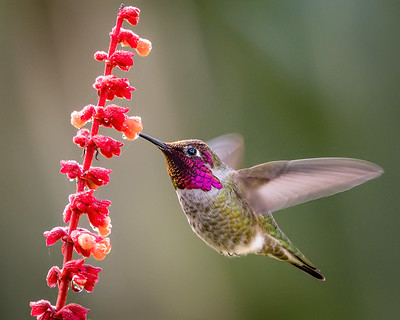

In [ ]:
from PIL import Image

img = Image.open("hummingbird.jpg")
img_np = np.array(img)
img

## Scatterplot of the pixels of the hummingbird image in R,G,B space

In [ ]:
plot_rgb_pixels_3d(img)

## Question 4 (2 points)

In this question, you will implement a simple color palette selection algorithm using K means. To find a 3 bits-per-pixel, 8-color palette, perform K-means with K=8 on the R,G,B values of the pixels in the image below. Reconstruct the image using just these 8 colors corresponding to 8 cluster means. Display the image both normally, by converting it to a PIL.Image, and using `plot_rgb_pixels_3d`.

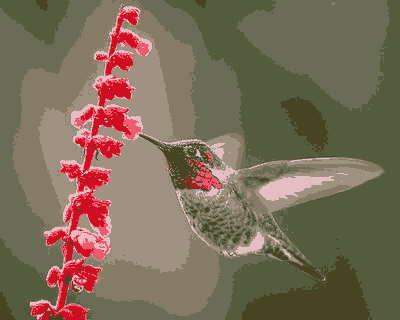

In [ ]:
# TODO: Perform K-means with k=8 on the set of (R,G,B) pixels from img_np dataset
# Convert the image to a numpy array
rgb_array = np.array(img)

# Reshape the array to a 2D array of RGB values
rgb_values = rgb_array.reshape(-1, 3)

# Take a random sample of pixels
# sampled_rgb = resample(rgb_values, n_samples=10000, random_state=42)
sampled_rgb=rgb_values

# Kmeans cluster k=8
kmeans = KMeans(8,random_state=32).fit(sampled_rgb)
centers = kmeans.cluster_centers_ # noramlized RGB centers
colors = []

# Match Color with corresponding cluster center
for i in kmeans.labels_:
  colors.append(centers[i].astype(int))

img = Image.open("hummingbird.jpg")
width, height = img.size

# Cartesian coordinate to index
def Index(x, y):
    return y*400 + x

# replace each pixel color with color of nearest center
for x in range(width):
  for y in range(height):
    i = Index(x,y)
    oldpixel = img.getpixel((x, y))
    newpixel = (colors[i][0],colors[i][1],colors[i][2]) # (r,g,b) val in colors
    img.putpixel((x, y), newpixel) #replace pixel
img

In [ ]:
# TODO: Reconstruct and display the image using your 8-color pallete.
plot_rgb_pixels_3d(img)

## Question 5 (2 points)

Now vary the number of colors in your pallete. How many colors are needed before your reconstructed image appears nearly indistinguishable from the original? How many bits per pixel do you save by using your color pallete, instead of the original 24-bit color space?

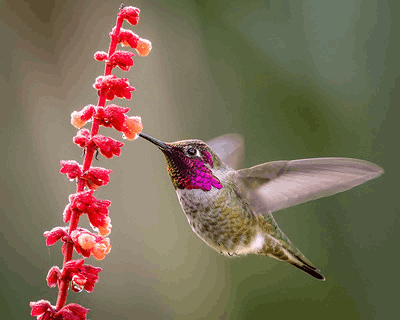

In [ ]:
# TODO: answer question 5
# Convert the image to a numpy array
img = Image.open("hummingbird.jpg")
rgb_array = np.array(img)

# Reshape the array to a 2D array of RGB values
rgb_values = rgb_array.reshape(-1, 3)

# Kmeans cluster k=128
kmeans = KMeans(128,random_state=32).fit(rgb_values)
centers = kmeans.cluster_centers_
colors = []

# Match Color with corresponding cluster center
for i in kmeans.labels_:
  colors.append(centers[i].astype(int))

img = Image.open("hummingbird.jpg")
width, height = img.size

# replace each pixel color with color of nearest center
for x in range(width):
  for y in range(height):
    i = Index(x,y) #function defined above
    oldpixel = img.getpixel((x, y))
    newpixel = (colors[i][0],colors[i][1],colors[i][2])
    img.putpixel((x, y), newpixel)
img

At k=128 or 7bits per pixel the image appears nearly identifcal to the original.
Saving 17 bits.